In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

In [2]:
# visualisation
full_df = pd.read_csv('/project/station_demo_data.csv')

In [3]:
full_df.head()
round(full_df[['total_persons']].describe(), -1)

,total_persons
count,760.0
mean,235830.0
std,45850.0
min,158650.0
25%,206120.0
50%,226770.0
75%,254100.0
max,307980.0


## Hiring Time per 100k Population by Borough

In [4]:
### DATA PREPARATION
# get the hirings
hires_borough = full_df.groupby(['borough']).mean('hired_min_per_100k')

# sort the values
hires_borough = hires_borough.sort_values('hired_min_per_100k', ascending=True)

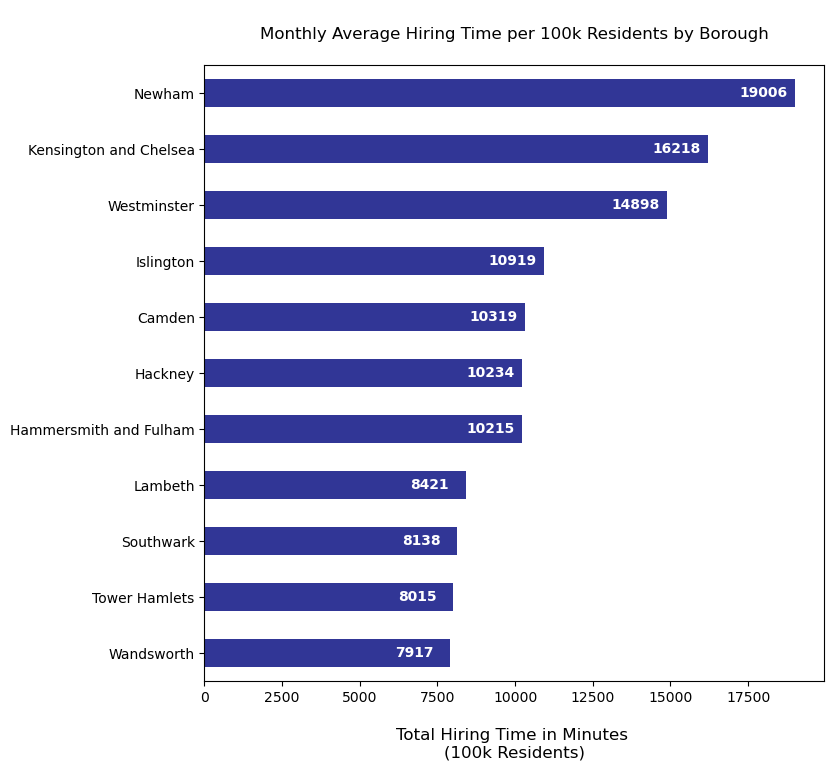

In [21]:
### AESTHETICS (leave on top) 
# list of blue colors
blue_colors=['#313696']

### PLOT
ax = hires_borough.plot(kind = 'barh', 
                   y = 'hired_min_per_100k', 
                   use_index = True, 
                   color = blue_colors, 
                  figsize = (8, 8), 
                  legend = None)

### LABELS
# Title
plt.title('\nMonthly Average Hiring Time per 100k Residents by Borough\n')

# Y-Label
plt.ylabel('')
plt.xlabel('\nTotal Hiring Time in Minutes \n(100k Residents)', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fontsize = 10,  color='white', padding=-40, fontweight='bold', fmt='%.0f')


plt.show()

In [9]:
# for the following graphs we want the same order of the boroughs
# create a list with the borough order

borough_order = ['Newham', 'Kensington and Chelsea', 'Westminster', 'Islington', 
                 'Camden', 'Hackney', 'Hammersmith and Fulham', 'Lambeth', 'Southwark', 'Tower Hamlets', 'Wandsworth']

## Age Distribution per Borough

In [10]:
###  DATA PREPARATION
age_borough = full_df.copy()
age_borough = age_borough.groupby(['borough']).mean()
age_borough['0_15_percentage'] = (age_borough['0_15_total'] / age_borough['total_persons']) * 100
age_borough['16_24_percentage'] = (age_borough['16_24_total'] / age_borough['total_persons']) * 100
age_borough['25_49_percentage'] = (age_borough['25_49_total'] / age_borough['total_persons']) * 100
age_borough['50_64_percentage'] = (age_borough['50_64_total'] / age_borough['total_persons']) * 100
age_borough['over_65_percentage'] = (age_borough['65_over_total'] / age_borough['total_persons']) * 100

# arrange the dataframe so that we have the same borough series
age_borough = age_borough.reindex(borough_order[::-1])


# drop total persons
age_borough = age_borough[['0_15_percentage',
                   '16_24_percentage', 
                   '25_49_percentage',
                   '50_64_percentage',
                   'over_65_percentage']]

Text(0.5, 1.0, 'Age Distribution by Borough\n')

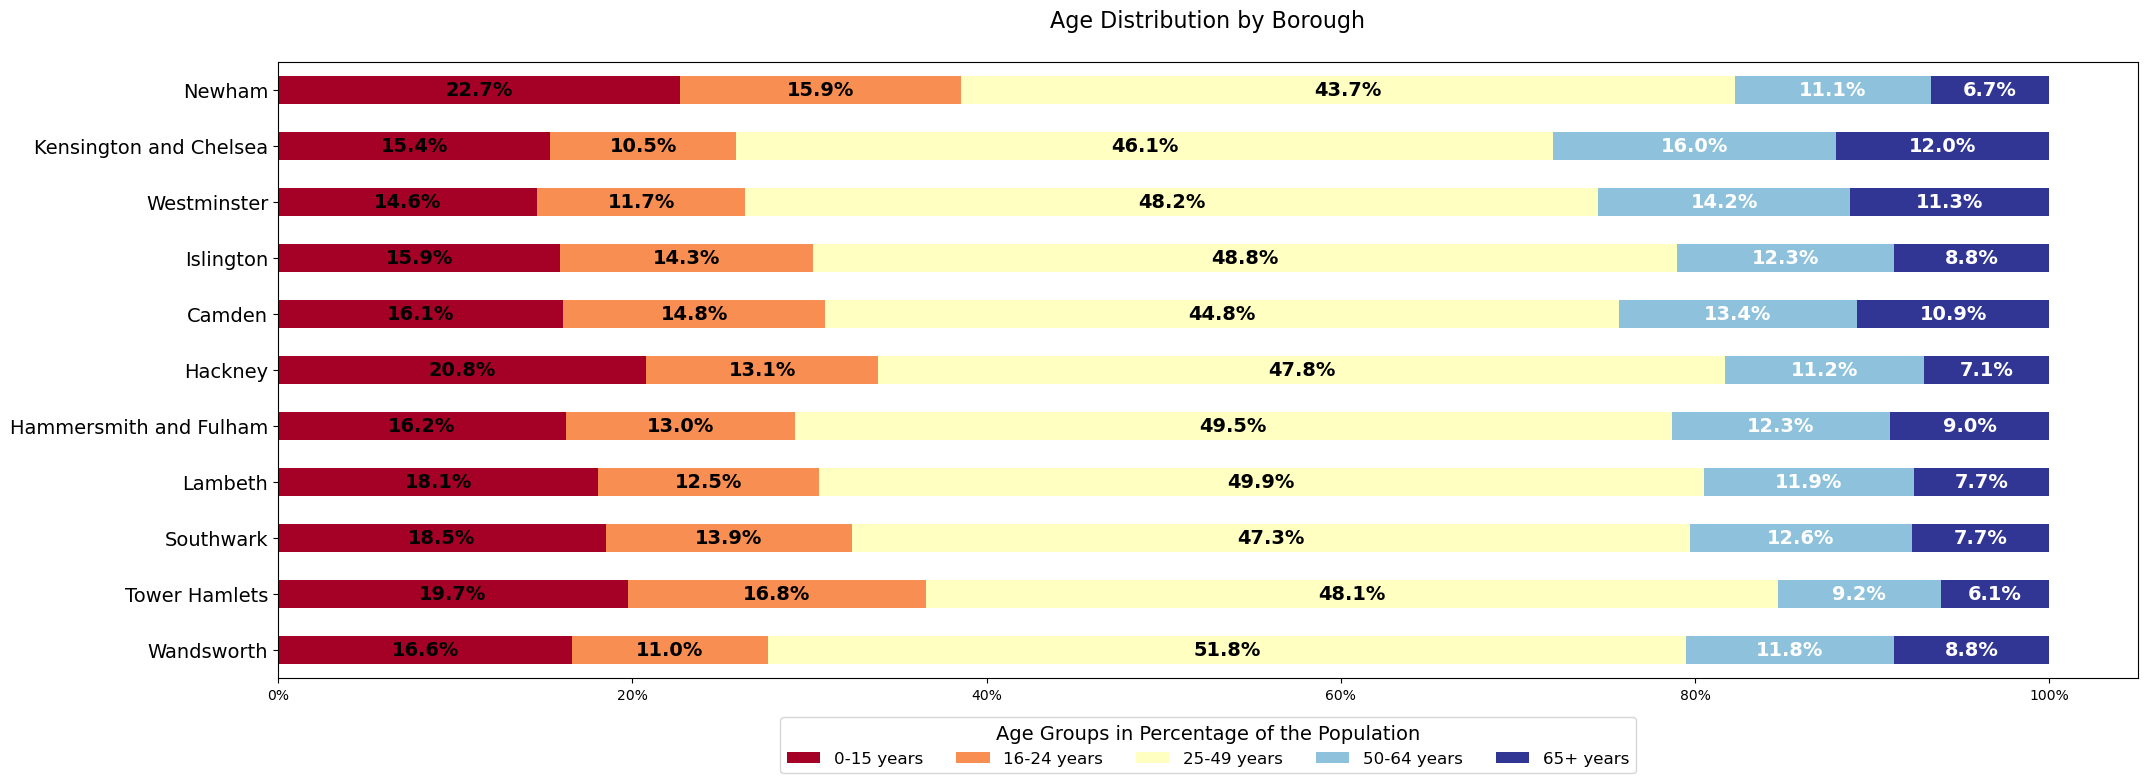

In [11]:
### AESTHETICS (leave on top) 
# list of blue colors
blue_colors= [plt.cm.Blues(i/5) for i in range(1,6)]

# Choose a diverging colormap
colormap = plt.cm.get_cmap('RdYlBu')  

# Calculate the number of color shades needed
num_of_colors = len(age_borough.columns)

# Generate the colors from the colormap
blue_colors = [colormap(i) for i in np.linspace(0, 1, num_of_colors)]

### PLOT INITIALISATION
# create plot
ax = age_borough.plot.barh(
    stacked = True,
    use_index = True, 
figsize = (24,8), 
color = blue_colors )

### LEGEND
new_labels = ['0-15 years', '16-24 years', '25-49 years', '50-64 years', '65+ years']

legend = ax.legend(title='Age Groups in Percentage of the Population', bbox_to_anchor=(0.5, -0.05), 
          loc='upper center', ncol=len(age_borough.columns), fontsize=12, 
                  labels = new_labels)
plt.setp(legend.get_title(), fontsize='14')


### LABELS 
# Y - axis: No label
plt.ylabel('')
ax.tick_params(axis='y', labelsize=14)

# X axis percentages
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Percentage values inside the bars
for bars in ax.containers:
    # better readability: bar label color to white for the last two age groups (50-64 years and 65+ years)
    bar_label_color = 'white' if bars == ax.containers[-2] or bars == ax.containers[-1] else 'black'
    
    ax.bar_label(bars, fmt='%.1f%%', label_type='center', color=bar_label_color, fontsize = 14, fontweight='bold')

# Title
plt.title('Age Distribution by Borough\n', fontsize=16)



## Gender Distribution per Borough

In [12]:
### DATA PREPARATION 
# Preparing for male percentage in each borough
gender_borough = full_df.copy()
gender_borough = gender_borough.groupby(['borough']).mean()

# arrange the dataframe so that we have the same borough series
gender_borough = gender_borough.reindex(borough_order[::-1])

# keeping only columns needed for the visualisation
gender_borough = gender_borough[['male_percentage']]

# adding a column with the women percentage
gender_borough['female_percentage'] = abs(100 - gender_borough["male_percentage"])


Text(0.5, 1.0, 'Gender Distribution by Borough\n')

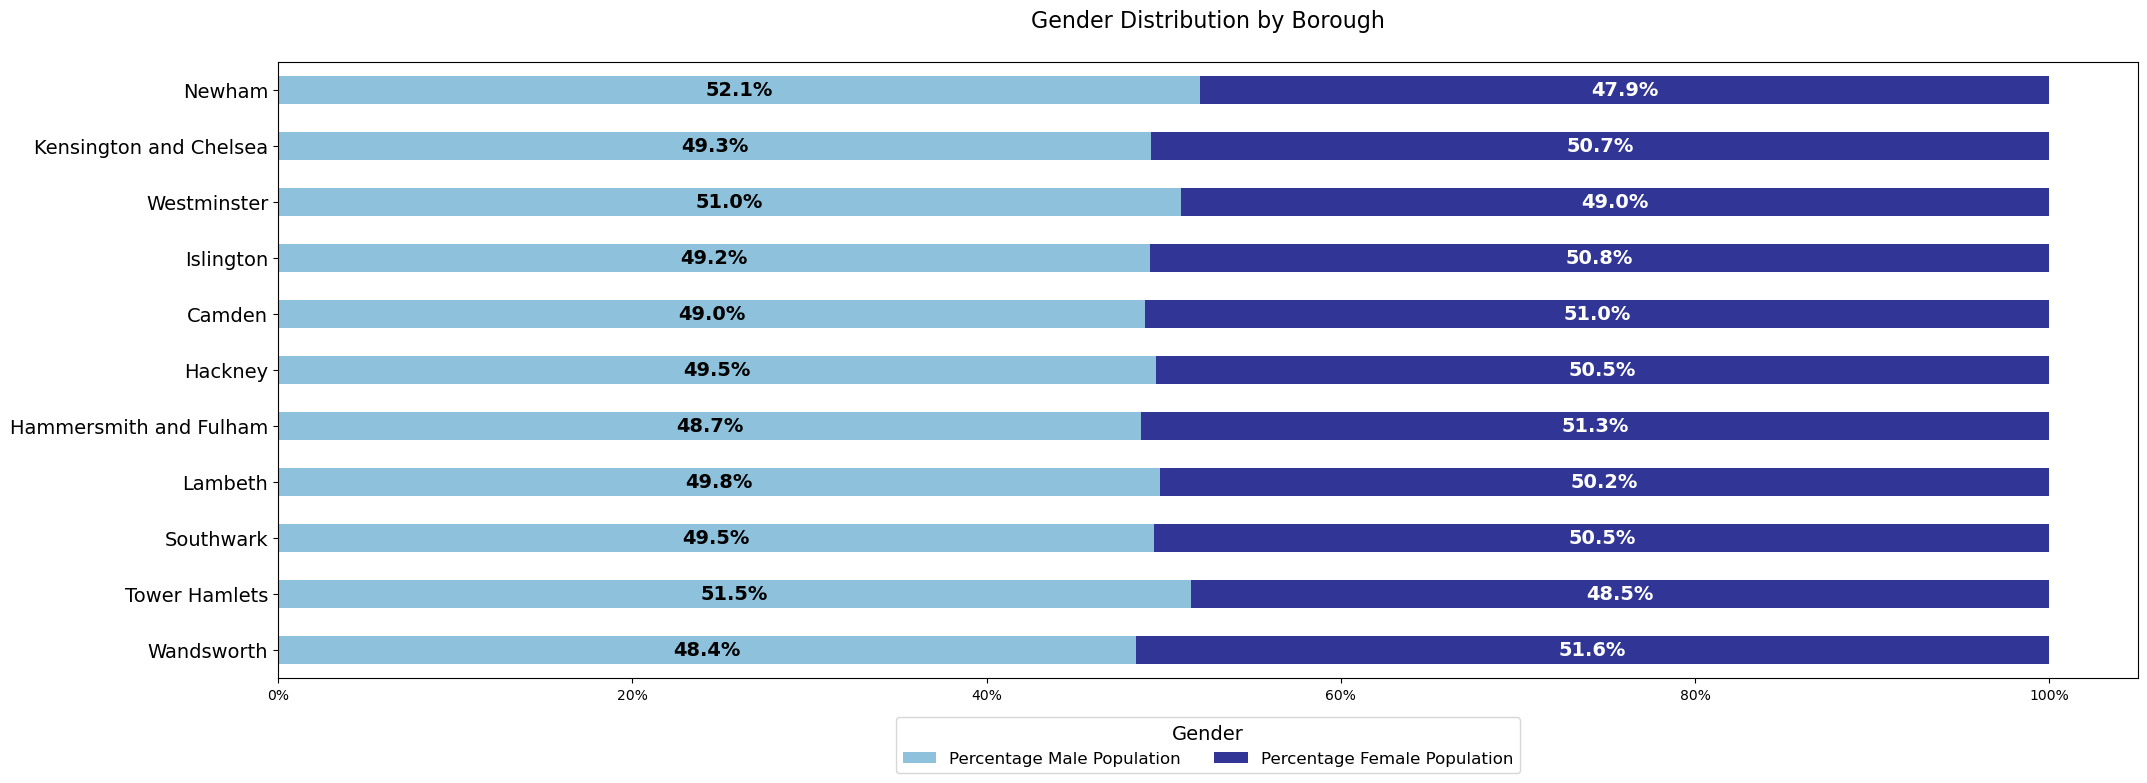

In [13]:
### AESTHETICS (leave on top) 
# list of blue colors
# blue_colors= [plt.cm.Blues(i/10) for i in range(2,12,5)]

blue_colors = ['#8EC2DC', '#313696']

### PLOT INITIALISATION
# create plot
ax = gender_borough.plot.barh(
    stacked = True,
    use_index = True, 
figsize = (24,8), 
color = blue_colors )

### LEGEND
new_labels = ['Percentage Male Population', 'Percentage Female Population']

legend = ax.legend(title='Gender', bbox_to_anchor=(0.5, -0.05), 
          loc='upper center', ncol=len(age_borough.columns), fontsize=12, 
                  labels = new_labels)
plt.setp(legend.get_title(), fontsize='14')


### LABELS 
# Y - axis: No label
plt.ylabel('')

# X axis percentages
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='y', labelsize=14)

# Get the percentage values inside the bars
for bars in ax.containers:
    # better readability: bar label color to white for the last two age groups (50-64 years and 65+ years)
    bar_label_color = 'white' if bars == ax.containers[-1] or bars == ax.containers[-1] else 'black'
    
    ax.bar_label(bars, fmt='%.1f%%', label_type='center', color=bar_label_color, fontsize=14, fontweight='bold')
    
# Title
plt.title('Gender Distribution by Borough\n', fontsize=16)

## Profession per Borough

In [14]:
### DATA PREPARATION  --------------------------------------------------------
profession_borough = full_df.copy()
profession_borough = profession_borough.groupby(['borough']).mean()

profession_borough = profession_borough[['occupation_1',
                                         'occupation_2',
                                         'occupation_3',
                                         'occupation_4',
                                         'occupation_5',
                                         'occupation_6',
                                         'occupation_7',
                                         'occupation_8',
                                         'occupation_9',
                                         'total_workforce' ]]

# get the percentages
for i in range(1, 10):  # we have 9 occupations
    profession_column = 'occupation_' + str(i) # existing col names
    percentage_column = 'prof' + str(i) + '_percentage' # new col names
    # Calculate the percentage
    profession_borough[percentage_column] = (profession_borough[profession_column] / profession_borough['total_workforce']) * 100

    
# for the visualisation keep only the percentage columns 
profession_borough = profession_borough[['prof1_percentage',
                                         'prof2_percentage',
                                         'prof3_percentage',
                                         'prof4_percentage',
                                         'prof5_percentage',
                                         'prof6_percentage',
                                         'prof7_percentage',
                                         'prof8_percentage',
                                         'prof9_percentage' ]]

# arrange the dataframe so that we have the same borough series
profession_borough = profession_borough.reindex(borough_order[::-1])

profession_borough.head()


,prof1_percentage,prof2_percentage,prof3_percentage,prof4_percentage,prof5_percentage,prof6_percentage,prof7_percentage,prof8_percentage,prof9_percentage
borough,,,,,,,,,
Wandsworth,14.368114,28.940197,21.880416,10.023462,5.222945,6.080061,5.127091,2.427566,5.930149
Tower Hamlets,10.977863,25.644980,20.371317,9.867705,6.001946,5.952460,7.871730,3.742866,9.569133
Southwark,10.554411,25.768438,17.372209,9.876009,6.556978,8.255684,6.548870,3.446738,11.620663
Lambeth,10.918334,25.690619,20.146527,10.102569,6.437607,7.439969,6.074579,3.022637,10.167160
Hammersmith and Fulham,14.600391,26.999041,22.091305,9.644726,5.462915,6.508368,5.439949,2.534249,6.719056


Text(0.5, 1.0, 'Professions by Borough\n')

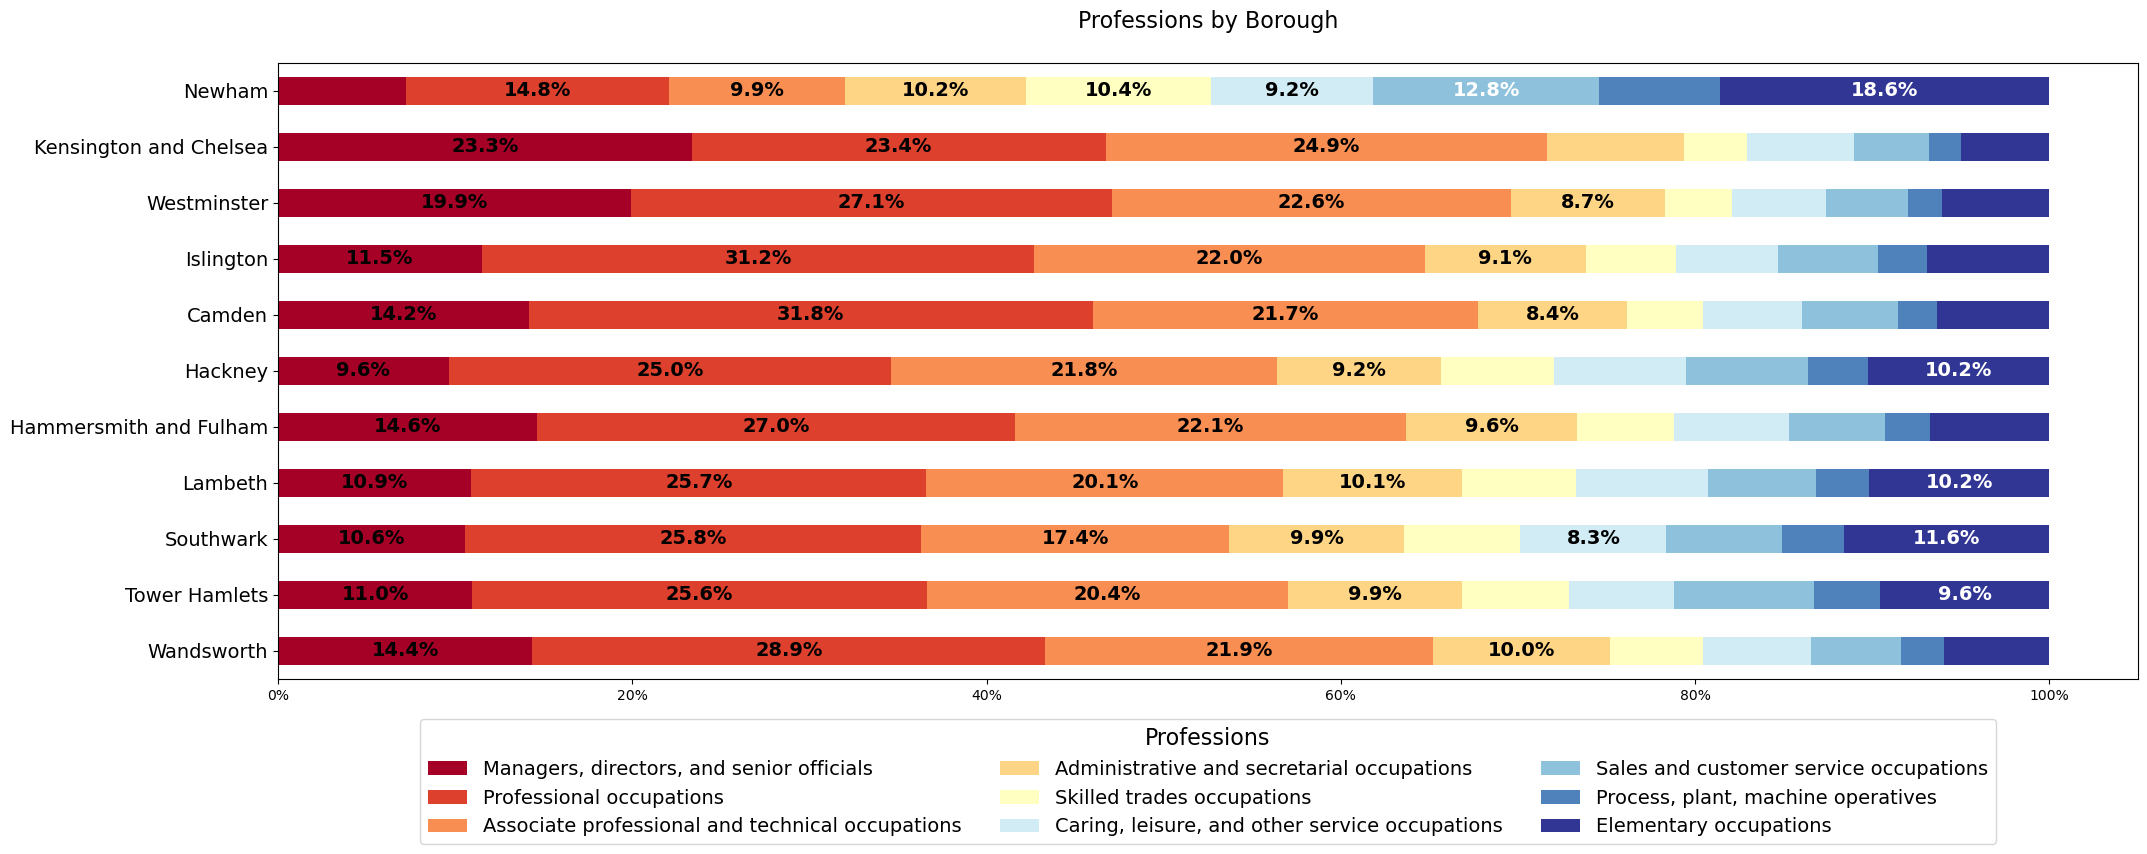

In [20]:
### AESTHETICS (leave on top) --------------------------------------------------------
# list of blue colors
# blue_colors= [plt.cm.Blues(i/9) for i in range(2, 83)]

# Choose a diverging colormap
colormap = plt.cm.get_cmap('RdYlBu')  

# Calculate the number of color shades needed
num_of_colors = len(profession_borough.columns)

# Generate the colors from the colormap
blue_colors = [colormap(i) for i in np.linspace(0, 1, num_of_colors)]

### PLOT --------------------------------------------------------
ax = profession_borough.plot.barh(use_index = True, 
                                  stacked = True, 
                                  figsize = (24,8), 
                                  color = blue_colors)

### LEGEND
new_labels = ['Managers, directors, and senior officials', 'Professional occupations', 'Associate professional and technical occupations', 
              'Administrative and secretarial occupations', 'Skilled trades occupations', 'Caring, leisure, and other service occupations', 
             'Sales and customer service occupations', 'Process, plant, machine operatives', 'Elementary occupations']


legend = ax.legend(title='Professions', bbox_to_anchor=(0.5, -0.05), 
          loc='upper center', ncol=3, fontsize=14, 
                  labels = new_labels)

plt.setp(legend.get_title(), fontsize='16')


### LABELS --------------------------------------------------------
# Y axis: No label
plt.ylabel('')

# X axis percentages
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='y', labelsize=14)

white_label_indices = [6, 7, 8] 

for i, container in enumerate(ax.containers):
    labels = [f'{bar.get_width():.1f}%' if bar.get_width() >= 8 else '' for bar in container]
    # Set the bar label color based on the container index
    bar_label_color = 'white' if i in white_label_indices else 'black'
    ax.bar_label(container, labels=labels, label_type='center', color=bar_label_color, fontsize=14, fontweight='bold')

    
# Title
plt.title('Professions by Borough\n', fontsize=16)

## Cars by borough  (per 100k residents)

In [16]:
### DATA PREPARATION  --------------------------------------------------------
cars_borough = full_df.copy()
cars_borough = cars_borough.groupby(['borough']).mean()

# get only columns needed for the visualisation
cars_borough = cars_borough[["cars_per_100k"]]

# arrange the dataframe so that we have the same borough series
cars_borough = cars_borough.reindex(borough_order[::-1])

## Bike to commute  (per 100k residents)

In [17]:
# DATA PREPARATION --------------------------------------------------------
bike_commute_borough = full_df.copy()
bike_commute_borough = bike_commute_borough.groupby(['borough']).mean()

# get only columns needed for the visualisation
bike_commute_borough = bike_commute_borough[["bike_commuters_per_100k"]]

# arrange the dataframe so that we have the same borough series
bike_commute_borough = bike_commute_borough.reindex(borough_order[::-1])

bike_commute_borough

,bike_commuters_per_100k
borough,
Wandsworth,4321.57
Tower Hamlets,3192.49
Southwark,3780.31
Lambeth,4439.33
Hammersmith and Fulham,4065.91
Hackney,7029.68
Camden,3209.61
Islington,4950.39
Westminster,2476.95


## Average Number of Stations by Borough (per 100k residents)

In [18]:
# DATA PREPARATION  --------------------------------------------------------
stations_borough = full_df.copy()
stations_borough = stations_borough.groupby(['borough']).mean()

# get only columns needed for the visualisation
stations_borough = stations_borough[["total_stations_per_100k"]]

# arrange the dataframe so that we have the same borough series
stations_borough = stations_borough.reindex(borough_order[::-1])

stations_borough

,total_stations_per_100k
borough,
Wandsworth,19.54
Tower Hamlets,46.05
Southwark,17.00
Lambeth,20.46
Hammersmith and Fulham,35.07
Hackney,16.24
Camden,32.22
Islington,22.32
Westminster,67.47


# Plotting All together

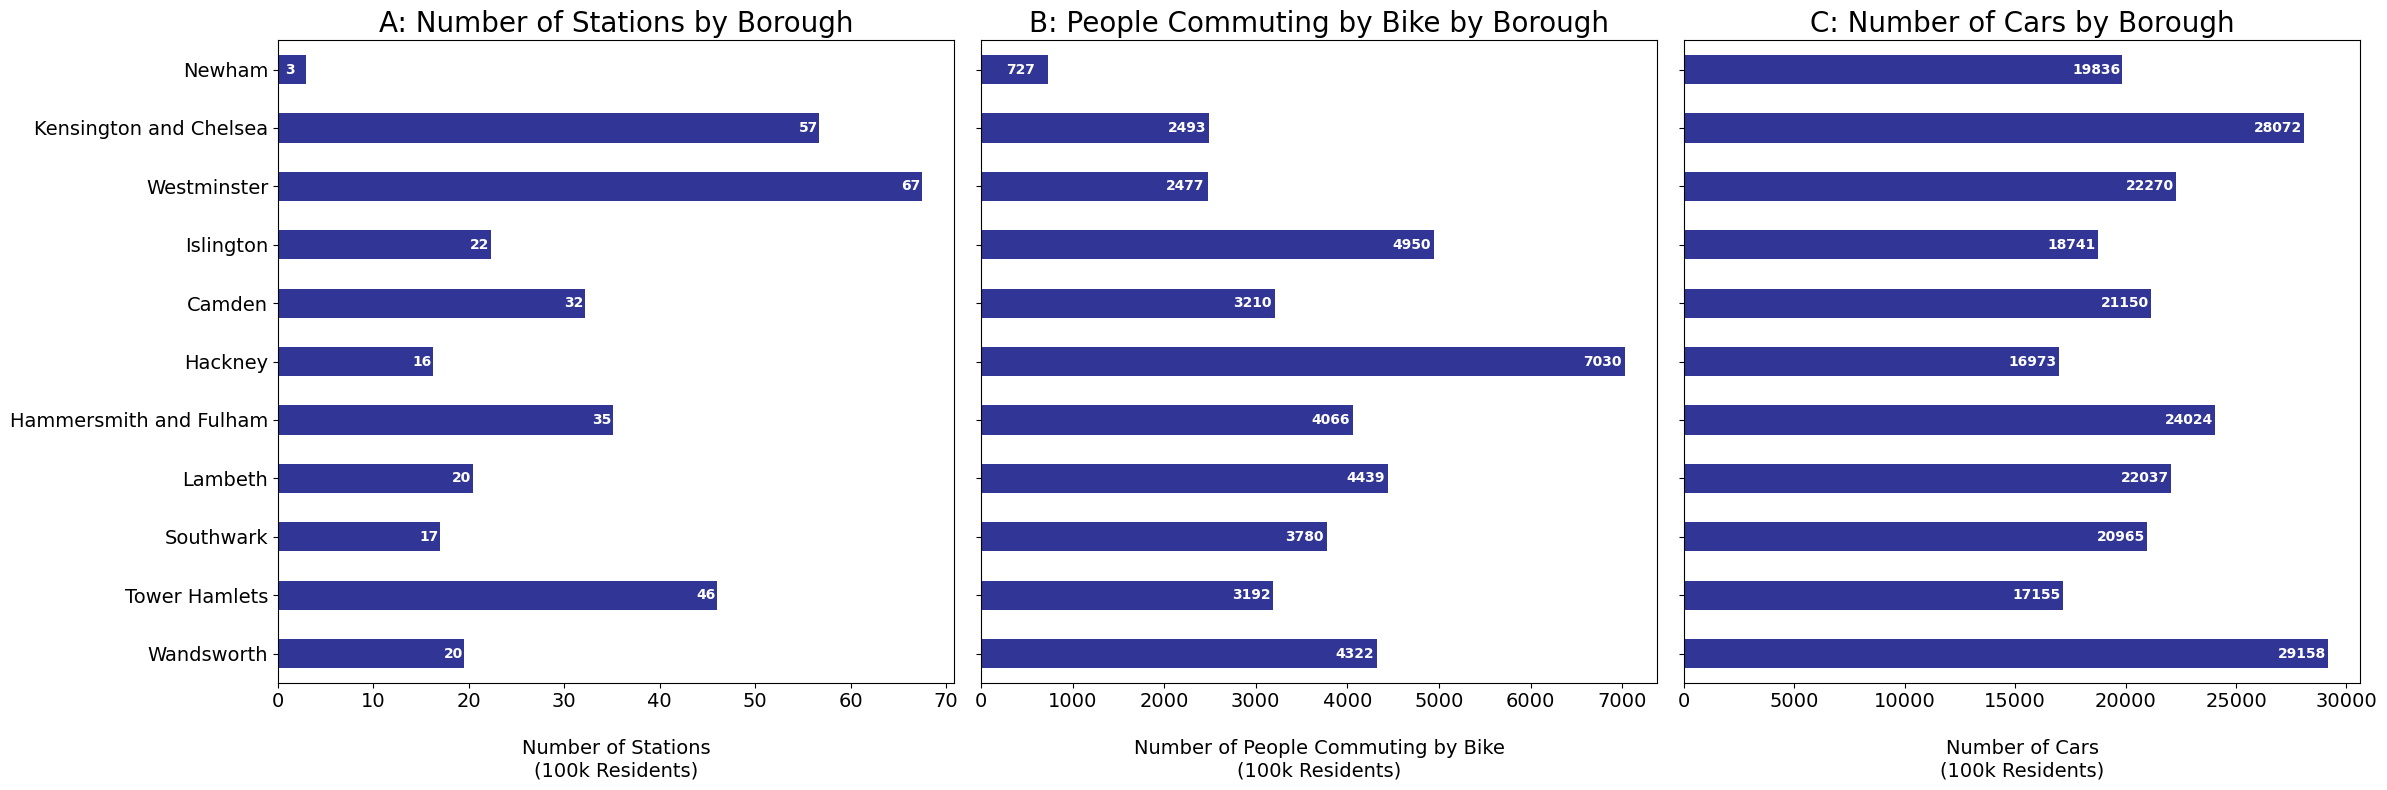

In [19]:
### AESTHETICS  --------------------------------------------------------
# colors for number in the plots 
color_legend = 'white' 

# bar colors
blue_colors=['#313696']

### FRAME FOR PLOTS  --------------------------------------------------------
# Create a figure and a set of subplots with 1 row and 2 columns
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))  # Adjust the figsize 

### FIRST PLOT: STATIONS  --------------------------------------------------------
stations_plot = stations_borough.plot(kind='barh', ax=ax1, color=blue_colors, legend=False, fontsize = 14)
# plt.yticks(np.arange(0, 1, step=3))
ax1.set_xlabel('\nNumber of Stations\n(100k Residents)', fontsize = 14)
ax1.set_title('A: Number of Stations by Borough', fontsize = 20)
ax1.set_ylabel('')

for container in stations_plot.containers:
    ax1.bar_label(container, fontsize = 10,  color=color_legend, padding=-15, fontweight='bold', fmt='%.0f')

# SECOND: PLOT BIKE COMMUTING  --------------------------------------------------------
bike_plot= bike_commute_borough.plot(kind='barh', ax=ax2, color=blue_colors, legend=False, fontsize = 14)
ax2.set_xlabel('\nNumber of People Commuting by Bike\n(100k Residents)', fontsize = 14)
ax2.set_title('B: People Commuting by Bike by Borough', fontsize = 20)
ax2.set_ylabel('')
ax2.set_yticklabels([])

for container in bike_plot.containers:
    ax2.bar_label(container, fontsize = 10,  color=color_legend, padding=-30, fontweight='bold', fmt='%.0f')

# THIRD PLOT: AMOUNT CARS  --------------------------------------------------------
cars_plot = cars_borough.plot(kind ='barh', ax=ax3, color=blue_colors, legend=False, fontsize = 14)
ax3.set_xlabel('\nNumber of Cars\n(100k Residents)', fontsize = 14)
ax3.set_title('C: Number of Cars by Borough', fontsize = 20)
ax3.set_ylabel('')
ax3.set_yticklabels([])

for container in cars_plot.containers:
    ax3.bar_label(container, fontsize = 10,  color=color_legend, padding=-36, fontweight='bold', fmt='%.0f')

### DISPLAY PLOT  --------------------------------------------------------
# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()